In [25]:
import numpy as np
import torch
from torch import nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt

In [26]:
# Actor network
class Actor(nn.Module):
  def __init__(self, state_size, action_size):
    super().__init__()
    self.anet = nn.Sequential(
        nn.Linear(state_size, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, action_size)
    )

  def forward(self, x):
    return self.anet(x)

# Critic network
class Critic(nn.Module):
  def __init__(self, state_size):
    super().__init__()
    self.cnet = nn.Sequential(
        nn.Linear(state_size, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )

  def forward(self, x):
    return self.cnet(x)

In [27]:
# instantiate the env & network
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
actor = Actor(state_size, action_size)
critic = Critic(state_size)
# hyperparamters
gamma = 0.99
lamb = 0.95
lr=1e-3

# define optimizer
actor_optimizer = optim.Adam(actor.parameters(), lr=lr)
critic_optimizer = optim.Adam(critic.parameters(), lr=lr)
# define loss function for critic
C_criterion = nn.MSELoss()

In [28]:
# obtain probability distribution
def prob_dist(obs):
  logits = actor(obs)
  dist = Categorical(logits=logits) # no tensor output yet, just a distribution object parameterized by those probs
  return dist
# select action
def get_action(obs):
  act = prob_dist(obs).sample()
  return act

# obtain TD error
def delta(rews, values): # should I use batch tensor value???
  errors = np.zeros_like(rews)
  for i in range(len(rews)):
    errors[i] = rews[i] + gamma * (0 if i+1 == len(rews) else values[i+1]) - values[i]
  return errors

# compute GAE
def gae(errors):
  adv = np.zeros_like(errors)
  n = len(errors)
  for i in reversed(range(n)):
    adv[i] = errors[i] + (gamma * lamb * adv[i+1] if i+1 < n else 0)
  return adv

# optimize function
def optimize(obs, act, adv):
  logprob = prob_dist(obs).log_prob(act)  # logprob shape:(T,)
  values = critic(obs).squeeze(-1)  # (T,)
  # target for updating critic: A(s_t, a_t) + V(s_t)
  target = adv + values
  # compute actor & critic loss
  actor_loss = -(logprob * adv.detach()).mean() # -(log_prob * GAE)
  critic_loss = C_criterion(values, target.detach())
  # update actor network
  actor_optimizer.zero_grad()
  actor_loss.backward()
  actor_optimizer.step()
  # update critic network
  critic_optimizer.zero_grad()
  critic_loss.backward()
  critic_optimizer.step()

In [29]:
max_episode = 500
episode_rew = []
# training loop
for i in range(max_episode):
  batch_obs, batch_rew, batch_act, batch_v = [], [], [], []
  epi_rew = 0
  obs, _ = env.reset()
  done = False
  obs = torch.tensor(obs, dtype=torch.float32).unsqueeze(0) # shape: (1,4)

  while not done:
    # record state
    batch_obs.append(obs)
    # take a step
    act = get_action(obs).item()
    next_obs, reward, terminated, truncated, _ = env.step(act)
    done = terminated or truncated
    next_obs = torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0) # shape: (1,4)
    epi_rew += reward
    # compute value function V(s_t)
    value = critic(obs).item()

    # record reward, act, value, done
    batch_act.append(act)
    batch_rew.append(reward)
    batch_v.append(value)

    obs = next_obs

    if done:
      # compute TD error
      TD_error = delta(batch_rew, batch_v)
      # compute GAE
      advantage = gae(TD_error)
      # optimize
      optimize(torch.cat(batch_obs).to(torch.float32),
               torch.tensor(batch_act, dtype=torch.int32),
               torch.tensor(advantage, dtype=torch.float32))

  # record total rewards in an episode
  episode_rew.append(epi_rew)
  print(f'Episode rewards: {epi_rew}')


Episode rewards: 15.0
Episode rewards: 19.0
Episode rewards: 21.0
Episode rewards: 18.0
Episode rewards: 27.0
Episode rewards: 25.0
Episode rewards: 24.0
Episode rewards: 11.0
Episode rewards: 21.0
Episode rewards: 21.0
Episode rewards: 12.0
Episode rewards: 42.0
Episode rewards: 72.0
Episode rewards: 17.0
Episode rewards: 12.0
Episode rewards: 33.0
Episode rewards: 48.0
Episode rewards: 47.0
Episode rewards: 23.0
Episode rewards: 21.0
Episode rewards: 15.0
Episode rewards: 67.0
Episode rewards: 21.0
Episode rewards: 68.0
Episode rewards: 10.0
Episode rewards: 15.0
Episode rewards: 12.0
Episode rewards: 37.0
Episode rewards: 38.0
Episode rewards: 14.0
Episode rewards: 24.0
Episode rewards: 15.0
Episode rewards: 21.0
Episode rewards: 28.0
Episode rewards: 24.0
Episode rewards: 27.0
Episode rewards: 18.0
Episode rewards: 32.0
Episode rewards: 21.0
Episode rewards: 29.0
Episode rewards: 9.0
Episode rewards: 21.0
Episode rewards: 19.0
Episode rewards: 14.0
Episode rewards: 35.0
Episode rew

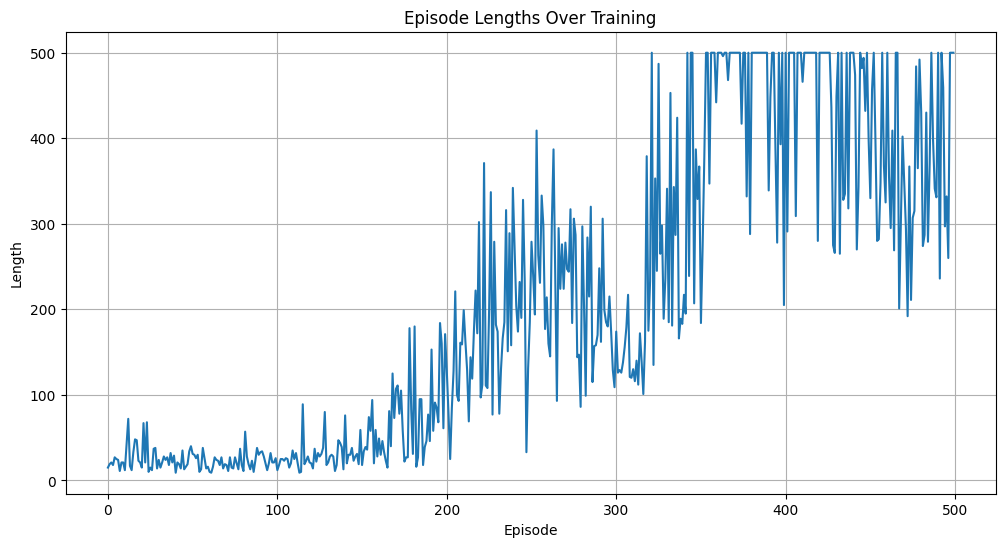

In [30]:
# Plot the collected episode lengths
plt.figure(figsize=(12, 6))
plt.plot(episode_rew)
plt.title('Episode Lengths Over Training')
plt.xlabel('Episode')
plt.ylabel('Length')
plt.grid(True)
plt.show()